# Import Libraries

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset

In [114]:
train_df = pd.read_csv(r"C:\Users\PROGRESSIVE\OneDrive\Documents\applications\LocalBuka\Learning Sessions\Datasets\Restaurant\train.csv")
train_df.head(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [115]:
test_df = pd.read_csv(r"C:\Users\PROGRESSIVE\OneDrive\Documents\applications\LocalBuka\Learning Sessions\Datasets\Restaurant\test.csv")
test_df.head(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City
0,0x2318,COIMBRES13DEL01,NaN,NaN,11.003669,76.976494,11.043669,77.016494,30-03-2022,NaN,15:05:00,conditions NaN,NaN,3,Drinks,electric_scooter,1,No,Metropolitian
1,0x3474,BANGRES15DEL01,28,4.6,12.975377,77.696664,13.085377,77.806664,29-03-2022,20:30:00,20:35:00,conditions Windy,Jam,0,Snack,motorcycle,1,No,Metropolitian
2,0x9420,JAPRES09DEL03,23,4.5,26.911378,75.789034,27.001378,75.879034,10-03-2022,19:35:00,19:45:00,conditions Stormy,Jam,0,Drinks,motorcycle,1,No,Metropolitian
3,0x72ee,JAPRES07DEL03,21,4.8,26.766536,75.837333,26.856536,75.927333,02-04-2022,17:15:00,17:20:00,conditions Fog,Medium,1,Meal,scooter,1,No,Metropolitian
4,0xa759,CHENRES19DEL01,31,4.6,12.986047,80.218114,13.096047,80.328114,27-03-2022,18:25:00,18:40:00,conditions Sunny,Medium,2,Drinks,scooter,1,No,Metropolitian


In [116]:
train_df = train_df.replace(r"^\s*NaN\s*$", np.nan, regex=True)
test_df = test_df.replace(r"^\s*NaN\s*$", np.nan, regex=True)

In [117]:
train_df["Weatherconditions"] = train_df["Weatherconditions"].replace(
    "conditions NaN", np.nan
)

test_df["Weatherconditions"] = test_df["Weatherconditions"].replace(
    "conditions NaN", np.nan
)

In [118]:
print("Dataset shape:", train_df.shape)

train_df.info()

Dataset shape: (45593, 20)
<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          43739 non-null  str    
 3   Delivery_person_Ratings      43685 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  43862 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            44977 non-null  str    
 12  Road_traffic_density         44992 non-null  str    
 13  

In [119]:
print("Dataset shape:", test_df.shape)

test_df.info()

Dataset shape: (11399, 19)
<class 'pandas.DataFrame'>
RangeIndex: 11399 entries, 0 to 11398
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           11399 non-null  str    
 1   Delivery_person_ID           11399 non-null  str    
 2   Delivery_person_Age          10908 non-null  str    
 3   Delivery_person_Ratings      10892 non-null  str    
 4   Restaurant_latitude          11399 non-null  float64
 5   Restaurant_longitude         11399 non-null  float64
 6   Delivery_location_latitude   11399 non-null  float64
 7   Delivery_location_longitude  11399 non-null  float64
 8   Order_Date                   11399 non-null  str    
 9   Time_Orderd                  10955 non-null  str    
 10  Time_Order_picked            11399 non-null  str    
 11  Weatherconditions            11241 non-null  str    
 12  Road_traffic_density         11245 non-null  str    
 13  

In [120]:
train_df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions               616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [121]:
test_df.isnull().sum()

ID                               0
Delivery_person_ID               0
Delivery_person_Age            491
Delivery_person_Ratings        507
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
Order_Date                       0
Time_Orderd                    444
Time_Order_picked                0
Weatherconditions              158
Road_traffic_density           154
Vehicle_condition                0
Type_of_order                    0
Type_of_vehicle                  0
multiple_deliveries            238
Festival                        65
City                           324
dtype: int64

In [122]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,distance_km,order_hour,pickup_hour,order_to_pickup_minutes
count,10908.0,10892.000000,11399.000000,11399.000000,11399.000000,11399.000000,11399.000000,11161.0,11285.000000,10955.000000,11399.000000,10955.000000
mean,29.517235,4.632786,17.099934,70.399259,17.569497,71.102187,1.031406,0.749664,9.755381,17.443907,17.188087,10.035600
std,5.797077,0.344081,8.193510,22.773144,7.287440,20.693782,0.839599,0.573657,5.605503,4.832357,5.320874,4.082141
min,15.0,1.000000,-30.902872,-88.400467,0.010000,0.010000,0.000000,0.0,1.465067,0.000000,0.000000,5.000000
25%,25.0,4.500000,12.933284,73.170937,12.992532,73.771081,0.000000,0.0,4.663439,15.000000,14.000000,5.000000
50%,30.0,4.700000,18.551440,75.897429,18.643481,75.996959,1.000000,1.0,9.220209,19.000000,19.000000,10.000000
75%,34.0,4.900000,22.732225,78.045732,22.791226,78.109004,2.000000,1.0,13.681492,21.000000,21.000000,15.000000
max,50.0,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.0,20.969489,23.000000,23.000000,15.000000


In [123]:
print("Duplicate rows:", train_df.duplicated().sum())

Duplicate rows: 0


In [124]:
print("Duplicate rows:", test_df.duplicated().sum())

Duplicate rows: 0


# Data Wrangling

In [125]:
# Remove whitespace from column names
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

In [126]:
# Remove whitespace from string columns
for df in [train_df, test_df]:
    string_columns = df.select_dtypes(include="str").columns
    for col in string_columns:
        df[col] = df[col].str.strip()

In [127]:
# Convert the numeric columns
for df in [train_df, test_df]:
    df["Delivery_person_Age"] = pd.to_numeric(
        df["Delivery_person_Age"], errors="coerce"
    ).astype("Int64")

    df["Delivery_person_Ratings"] = pd.to_numeric(
        df["Delivery_person_Ratings"], errors="coerce"
    )

    df["multiple_deliveries"] = pd.to_numeric(
        df["multiple_deliveries"], errors="coerce"
    ).astype("Int64")

In [128]:
# Remove unnecessary string in weatherconditions
for df in [train_df, test_df]:
    df["Weatherconditions"] = (
        df["Weatherconditions"]
        .str.replace("conditions ", "", regex=False)
        .str.strip()
    )

In [129]:
# remove unnecessary string in time taken
train_df["Time_taken(min)"] = (
    train_df["Time_taken(min)"]
    .str.replace("(min)", "", regex=False)
    .str.strip()
)

train_df["Time_taken(min)"] = pd.to_numeric(
    train_df["Time_taken(min)"],
    errors="coerce"
)

In [130]:
train_df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,Windy,High,1,Meal,motorcycle,0,No,Metropolitian,32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,26


In [131]:
test_df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City
0,0x2318,COIMBRES13DEL01,<NA>,NaN,11.003669,76.976494,11.043669,77.016494,30-03-2022,NaN,15:05:00,NaN,NaN,3,Drinks,electric_scooter,1,No,Metropolitian
1,0x3474,BANGRES15DEL01,28,4.6,12.975377,77.696664,13.085377,77.806664,29-03-2022,20:30:00,20:35:00,Windy,Jam,0,Snack,motorcycle,1,No,Metropolitian
2,0x9420,JAPRES09DEL03,23,4.5,26.911378,75.789034,27.001378,75.879034,10-03-2022,19:35:00,19:45:00,Stormy,Jam,0,Drinks,motorcycle,1,No,Metropolitian
3,0x72ee,JAPRES07DEL03,21,4.8,26.766536,75.837333,26.856536,75.927333,02-04-2022,17:15:00,17:20:00,Fog,Medium,1,Meal,scooter,1,No,Metropolitian
4,0xa759,CHENRES19DEL01,31,4.6,12.986047,80.218114,13.096047,80.328114,27-03-2022,18:25:00,18:40:00,Sunny,Medium,2,Drinks,scooter,1,No,Metropolitian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11394,0x6909,JAPRES01DEL01,35,4.6,26.905190,75.810753,27.015190,75.920753,27-03-2022,21:35:00,21:45:00,Sunny,Jam,1,Snack,scooter,1,No,Metropolitian
11395,0x443b,JAPRES11DEL01,33,4.9,26.902940,75.793007,26.912940,75.803007,11-03-2022,11:40:00,11:45:00,Sandstorms,High,1,Drinks,scooter,1,No,Metropolitian
11396,0x1ea5,SURRES11DEL03,<NA>,NaN,21.157735,72.768778,21.217735,72.828778,11-03-2022,NaN,21:05:00,NaN,NaN,3,Drinks,scooter,1,No,Metropolitian
11397,0x22d4,VADRES03DEL02,27,4.7,22.320000,73.170000,22.450000,73.300000,06-03-2022,18:35:00,18:40:00,Sandstorms,Medium,0,Meal,motorcycle,0,No,Metropolitian


In [132]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          43739 non-null  Int64  
 3   Delivery_person_Ratings      43685 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  43862 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            44977 non-null  str    
 12  Road_traffic_density         44992 non-null  str    
 13  Vehicle_condition          

In [133]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11399 entries, 0 to 11398
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           11399 non-null  str    
 1   Delivery_person_ID           11399 non-null  str    
 2   Delivery_person_Age          10908 non-null  Int64  
 3   Delivery_person_Ratings      10892 non-null  float64
 4   Restaurant_latitude          11399 non-null  float64
 5   Restaurant_longitude         11399 non-null  float64
 6   Delivery_location_latitude   11399 non-null  float64
 7   Delivery_location_longitude  11399 non-null  float64
 8   Order_Date                   11399 non-null  str    
 9   Time_Orderd                  10955 non-null  str    
 10  Time_Order_picked            11399 non-null  str    
 11  Weatherconditions            11241 non-null  str    
 12  Road_traffic_density         11245 non-null  str    
 13  Vehicle_condition          

# Feature Engineering

In [134]:
# Calculate delivery distance
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


train_df["distance_km"] = haversine_distance(
    train_df["Restaurant_latitude"],
    train_df["Restaurant_longitude"],
    train_df["Delivery_location_latitude"],
    train_df["Delivery_location_longitude"]
)

test_df["distance_km"] = haversine_distance(
    test_df["Restaurant_latitude"],
    test_df["Restaurant_longitude"],
    test_df["Delivery_location_latitude"],
    test_df["Delivery_location_longitude"]
)

In [135]:
print("Train Set:", train_df["distance_km"].describe())
print("\n")
print("Test Set:", test_df["distance_km"].describe())

Train Set: count    45593.000000
mean        99.303911
std       1099.731281
min          1.465067
25%          4.663493
50%          9.264281
75%         13.763977
max      19692.674606
Name: distance_km, dtype: float64


Test Set: count    11399.000000
mean       108.680168
std       1174.515324
min          1.465067
25%          4.663658
50%          9.312838
75%         13.766117
max      19693.743026
Name: distance_km, dtype: float64


In [136]:
# Treat implausibly large distances as missing values
train_df.loc[train_df["distance_km"] > 100, "distance_km"] = np.nan
test_df.loc[test_df["distance_km"] > 100, "distance_km"] = np.nan

In [137]:
# Extract useful features from the order times
def add_time_features(df):
    order_time = pd.to_datetime(
        df["Time_Orderd"],
        format="%H:%M:%S",
        errors="coerce"
    )

    pickup_time = pd.to_datetime(
        df["Time_Order_picked"],
        format="%H:%M:%S",
        errors="coerce"
    )

    df["order_hour"] = order_time.dt.hour
    df["pickup_hour"] = pickup_time.dt.hour

    df["order_to_pickup_minutes"] = (
        pickup_time - order_time
    ).dt.total_seconds() / 60

    # Handle orders picked up after midnight
    df.loc[
        df["order_to_pickup_minutes"] < 0,
        "order_to_pickup_minutes"
    ] += 1440

    return df

train_df = add_time_features(train_df)
test_df = add_time_features(test_df)

In [138]:
train_df[
    [
        "Time_Orderd",
        "Time_Order_picked",
        "order_hour",
        "pickup_hour",
        "order_to_pickup_minutes"
    ]
].head()

,Time_Orderd,Time_Order_picked,order_hour,pickup_hour,order_to_pickup_minutes
0,11:30:00,11:45:00,11.0,11,15.0
1,19:45:00,19:50:00,19.0,19,5.0
2,08:30:00,08:45:00,8.0,8,15.0
3,18:00:00,18:10:00,18.0,18,10.0
4,13:30:00,13:45:00,13.0,13,15.0


In [139]:
test_df[
    [
        "Time_Orderd",
        "Time_Order_picked",
        "order_hour",
        "pickup_hour",
        "order_to_pickup_minutes"
    ]
].head()

,Time_Orderd,Time_Order_picked,order_hour,pickup_hour,order_to_pickup_minutes
0,NaN,15:05:00,NaN,15,NaN
1,20:30:00,20:35:00,20.0,20,5.0
2,19:35:00,19:45:00,19.0,19,10.0
3,17:15:00,17:20:00,17.0,17,5.0
4,18:25:00,18:40:00,18.0,18,15.0


# Feature Selection

In [140]:
numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries",
    "distance_km",
    "order_hour",
    "pickup_hour",
    "order_to_pickup_minutes"
]

categorical_features = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

In [141]:
# Split the data into X and y sets
X_train = train_df[numeric_features + categorical_features]
y_train = train_df["Time_taken(min)"]

X_test = test_df[numeric_features + categorical_features]

# Preprocessing Pipeline

In [142]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine the preprocessed sets
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Model Development

In [143]:
# Create a validation set
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [144]:
# Train the models
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

# Fit the model
ridge_pipeline.fit(X_train_model, y_train_model)
rf_pipeline.fit(X_train_model, y_train_model)
gb_pipeline.fit(X_train_model, y_train_model)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Delivery_person_Age','Delivery_person_Ratings','Vehicle_condition',..., 'Type_of_vehicle','Festival','City']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically

In [145]:
# Evaluate the model's performance
models = {
    "Ridge": ridge_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline
}

results = []

for name, model in models.items():
    predictions = model.predict(X_val)

    mae = mean_absolute_error(y_val, predictions)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))
    r2 = r2_score(y_val, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R²
0,Ridge,4.793250,6.030516,0.585220
1,Random Forest,3.216660,4.060642,0.811939
2,Gradient Boosting,3.625998,4.539403,0.764979


# Model Fine Tuning

In [146]:
# Fine tune Random Forest Regressor
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_model, y_train_model)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` d

In [147]:
rf_search.best_params_

{'model__n_estimators': 200,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 2,
 'model__max_features': 1.0,
 'model__max_depth': 20}

In [148]:
rf_search.best_score_

np.float64(-3.188634835035798)

In [149]:
# Evaluate the tuned Random Forest Model
tuned_predictions = rf_search.predict(X_val)

tuned_mae = mean_absolute_error(y_val, tuned_predictions)
tuned_rmse = np.sqrt(mean_squared_error(y_val, tuned_predictions))
tuned_r2 = r2_score(y_val, tuned_predictions)

print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R²:", tuned_r2)

MAE: 3.1871687768950836
RMSE: 4.007060350075768
R²: 0.8168695954521189


In [150]:
# Identify model errors
error_df = X_val.copy()

error_df["actual"] = y_val
error_df["predicted"] = tuned_predictions
error_df["error"] = error_df["actual"] - error_df["predicted"]
error_df["absolute_error"] = np.abs(error_df["error"])

error_df.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,distance_km,order_hour,pickup_hour,order_to_pickup_minutes,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,Festival,City,actual,predicted,error,absolute_error
39858,<NA>,NaN,3,1,NaN,NaN,21,NaN,NaN,NaN,Snack,motorcycle,No,Metropolitian,54,26.829952,27.170048,27.170048
23469,<NA>,NaN,0,1,NaN,NaN,0,NaN,Cloudy,Low,Drinks,motorcycle,No,Metropolitian,44,21.283083,22.716917,22.716917
38512,37,4.7,0,1,NaN,21.0,21,10.0,Sunny,Jam,Drinks,motorcycle,No,Metropolitian,43,23.900225,19.099775,19.099775
30893,<NA>,NaN,0,1,6.116387,NaN,14,NaN,Sunny,High,Snack,motorcycle,No,Metropolitian,53,34.266860,18.733140,18.733140
16930,<NA>,NaN,0,1,6.210608,NaN,13,NaN,NaN,NaN,Buffet,motorcycle,Yes,Metropolitian,48,30.186339,17.813661,17.813661
30538,<NA>,NaN,0,1,20.852514,NaN,18,NaN,Sandstorms,Medium,Snack,motorcycle,No,Metropolitian,20,37.673841,-17.673841,17.673841
25807,<NA>,NaN,1,0,4.674324,19.0,20,5.0,Sandstorms,Jam,Meal,scooter,No,Metropolitian,11,28.459582,-17.459582,17.459582
24884,<NA>,NaN,3,1,6.290135,NaN,17,NaN,NaN,NaN,Meal,bicycle,No,Urban,11,27.366299,-16.366299,16.366299
12947,<NA>,NaN,1,1,16.721296,NaN,22,NaN,Sandstorms,Jam,Drinks,scooter,No,Metropolitian,44,27.644643,16.355357,16.355357
39699,50,6.0,3,1,4.717601,NaN,21,NaN,NaN,NaN,Buffet,bicycle,No,Metropolitian,39,23.209695,15.790305,15.790305


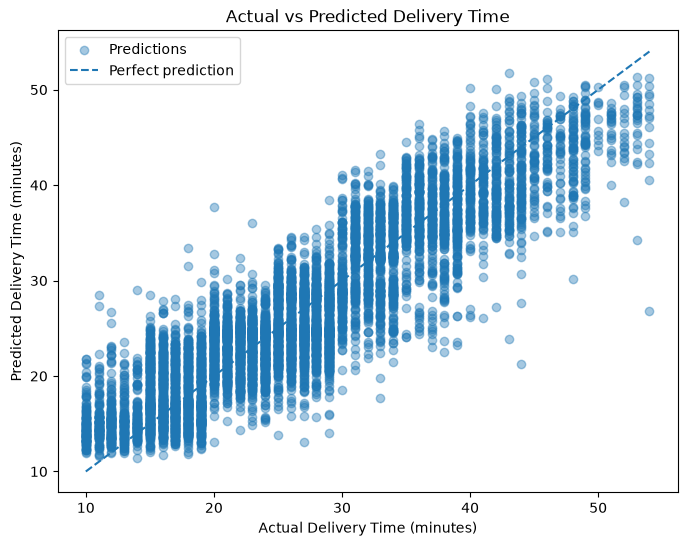

In [151]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_val,
    tuned_predictions,
    alpha=0.4,
    label="Predictions"
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time")
plt.legend()

plt.show()

In [155]:
# Generate predictions for the unseen test set
test_predictions = rf_search.predict(X_test)

test_results = pd.DataFrame({
    "ID": test_df["ID"],
    "Predicted_Time_taken": test_predictions
})

test_results.to_csv("test_predictions.csv", index=False)